In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils.data_utils import TitanicDataHelper
import warnings
from utils.evaluation_utils import EvaluationHelper
warnings.filterwarnings("ignore")

## Data Visualization

In [2]:
x_train, x_test, y_train, y_test = TitanicDataHelper.load_dataset()
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((712, 8), (179, 8), (712,), (179,))

In [3]:
x_train.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
709,0.824654,-0.091831,0.445182,0.705697,-0.339157,0.741906,-0.308627,-1.593335
439,-0.376069,0.132682,-0.481630,-0.493483,-0.429806,0.741906,-0.308627,0.626733
840,0.824654,-0.690532,-0.481630,-0.493483,-0.478991,0.741906,-0.308627,0.626733
720,-0.376069,-1.738261,-0.481630,0.705697,-0.000034,-1.345987,-0.308627,0.626733
39,0.824654,-1.139559,0.445182,-0.493483,-0.415639,-1.345987,-0.308627,-1.593335


In [4]:
y_train.head()

709    1
439    0
840    0
720    1
39     1
Name: Survived, dtype: int64

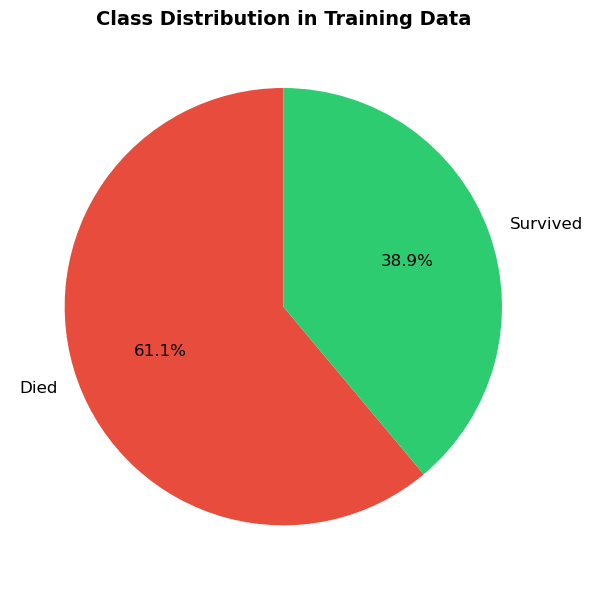

Died: 435 (61.1%)
Survived: 277 (38.9%)


In [5]:
TitanicDataHelper.plot_outcome_distribution(x_train, y_train)

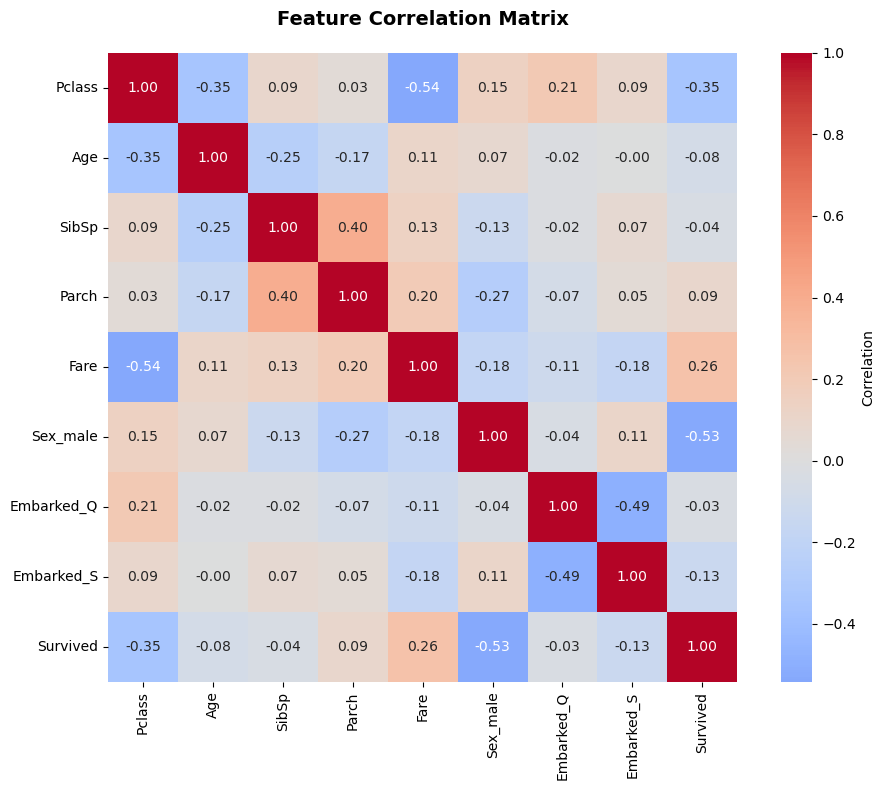

In [6]:
TitanicDataHelper.plot_correlation(x_train, y_train)

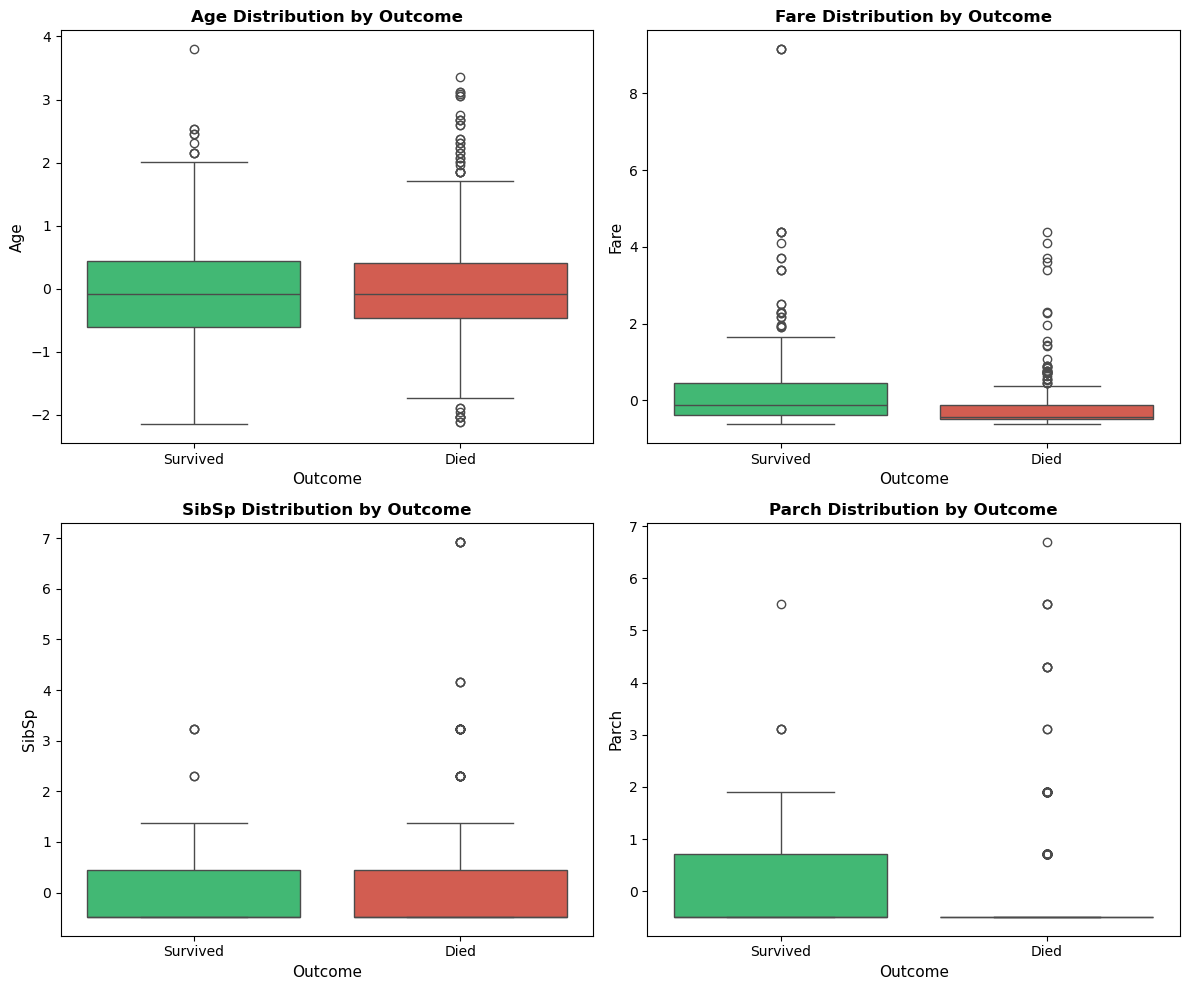

In [7]:
TitanicDataHelper.plot_boxplots(x_train, y_train)

## Model Training

In [8]:
x_train = np.array(x_train)
x_test = np.array(x_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

In [9]:
n_features = x_train.shape[1]
weights = np.random.normal(0, np.sqrt(2.0 / n_features), size=(n_features))
bias = 0

weights.shape

(8,)

In [10]:
def sigmoid(linear):
    return 1 / (1 + np.exp(-linear))

In [11]:
def forward(x):
    linear = np.dot(x, weights) + bias
    return sigmoid(linear)

In [12]:
def compute_loss(y_true, prob):
    epsilon = 1e-15
    prob = np.clip(prob, epsilon, 1 - epsilon)
    loss = -(y_true * np.log(prob) + (1 - y_true) * np.log(1 - prob))
    return loss

In [13]:
def backward(x, prob, y_true, learning_rate=0.01):
    global weights, bias
    
    dw = x * (prob - y_true)
    db = prob - y_true
    
    weights -= dw * learning_rate
    bias -= db * learning_rate

In [14]:
epochs = 500
epoch_losses = []

learning_rate = 0.01

for epoch in range(epochs):
    total_loss = 0
    
    for idx in range(len(x_train)):
        prob = forward(x_train[idx])
        
        loss = compute_loss(y_train[idx], prob)
        total_loss += loss
        
        backward(x_train[idx], prob, y_train[idx], learning_rate)
    
    avg_loss = total_loss / len(x_train)

    epoch_losses.append(avg_loss)
    print(f"Epoch: {epoch + 1}/{epochs} | Avg. Loss: {avg_loss}")

Epoch: 1/500 | Avg. Loss: 0.7835903540492355
Epoch: 2/500 | Avg. Loss: 0.48531010007614706
Epoch: 3/500 | Avg. Loss: 0.4584381222527319
Epoch: 4/500 | Avg. Loss: 0.45253836253825175
Epoch: 5/500 | Avg. Loss: 0.45075477381574663
Epoch: 6/500 | Avg. Loss: 0.4501108539096564
Epoch: 7/500 | Avg. Loss: 0.44984983724682925
Epoch: 8/500 | Avg. Loss: 0.4497346871853018
Epoch: 9/500 | Avg. Loss: 0.44968029978226604
Epoch: 10/500 | Avg. Loss: 0.4496530338035392
Epoch: 11/500 | Avg. Loss: 0.4496385959145642
Epoch: 12/500 | Avg. Loss: 0.44963055201543767
Epoch: 13/500 | Avg. Loss: 0.44962585771050245
Epoch: 14/500 | Avg. Loss: 0.4496230042305006
Epoch: 15/500 | Avg. Loss: 0.44962120926796556
Epoch: 16/500 | Avg. Loss: 0.44962004858026655
Epoch: 17/500 | Avg. Loss: 0.44961928179604643
Epoch: 18/500 | Avg. Loss: 0.4496187669912857
Epoch: 19/500 | Avg. Loss: 0.449618417214509
Epoch: 20/500 | Avg. Loss: 0.4496181774892827
Epoch: 21/500 | Avg. Loss: 0.4496180121531618
Epoch: 22/500 | Avg. Loss: 0.44961

In [15]:
def predict(x):
    prob = forward(x)
    return prob >= 0.5, prob

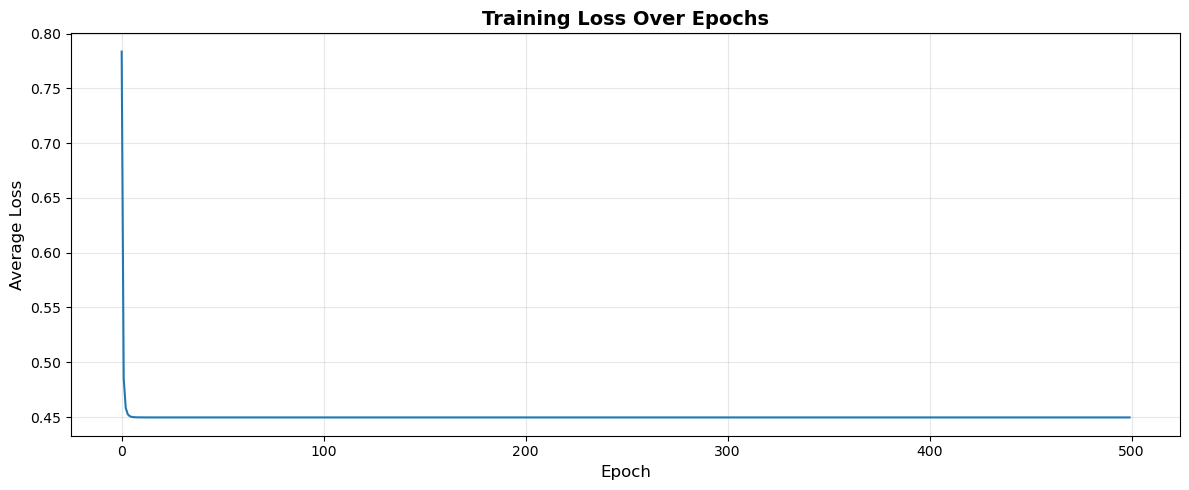

Initial loss: 0.783590
Final loss: 0.449618
Loss reduction: 42.62%


In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(epoch_losses, linewidth=1.5)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Average Loss", fontsize=12)
ax.set_title("Training Loss Over Epochs", fontsize=14, fontweight="bold")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial loss: {epoch_losses[0]:.6f}")
print(f"Final loss: {epoch_losses[-1]:.6f}")
print(f"Loss reduction: {(epoch_losses[0] - epoch_losses[-1])/epoch_losses[0]*100:.2f}%")

## Model Evaluation

In [17]:
predictions = []
probabilities = []

for x in x_test:
    prediction, prob = predict(x)
    predictions.append(prediction)
    probabilities.append(prob)

predictions = np.array(predictions)
probabilities = np.array(probabilities)

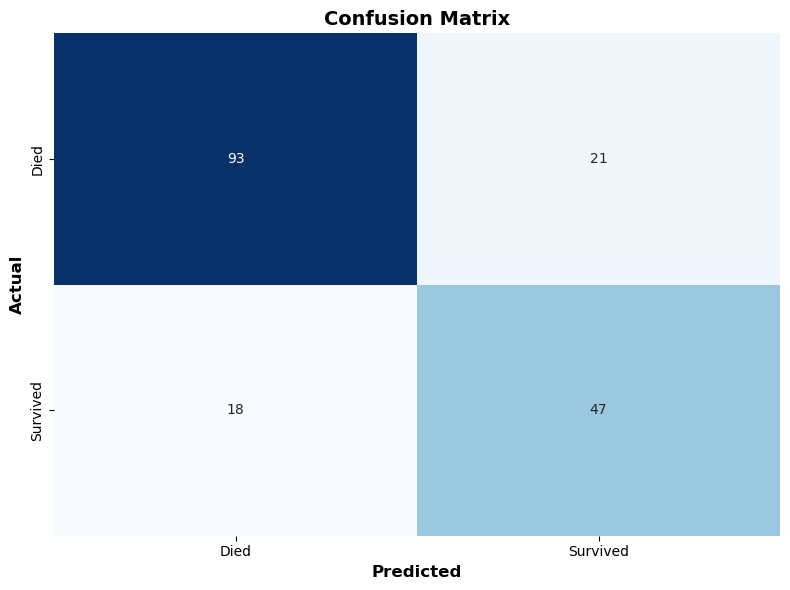

True Negatives: 93
False Positives: 21
False Negatives: 18
True Positives: 47

Sensitivity (Recall): 0.7231
Specificity: 0.8158
Precision: 0.6912
Accuracy: 0.7821
F1 Score: 0.7068


In [18]:
EvaluationHelper.plot_confusion_matrix(y_test, predictions, class_names=["Died", "Survived"])

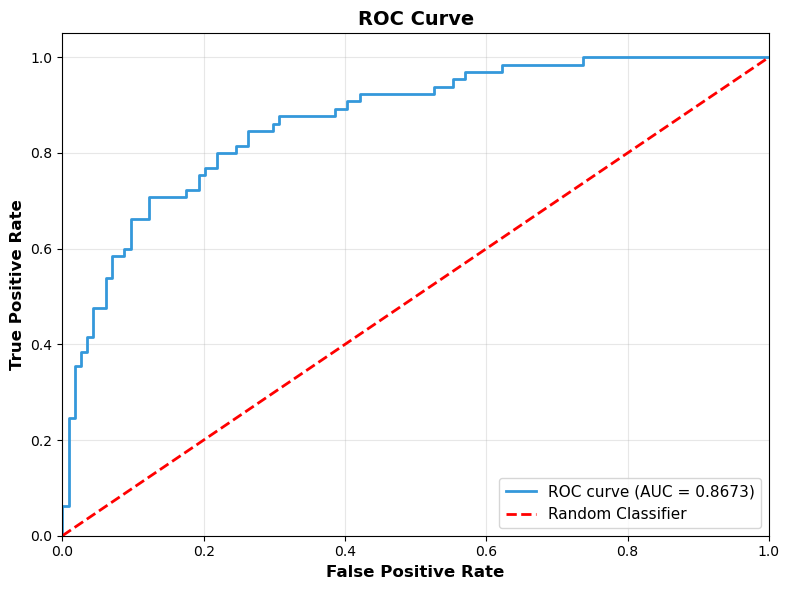

Area Under the Curve (AUC): 0.8673


In [19]:
EvaluationHelper.plot_roc_curve(y_test, probabilities)